Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


Best Threshold: 0.2149999999999999
Validation AUC: 0.8766982909194219


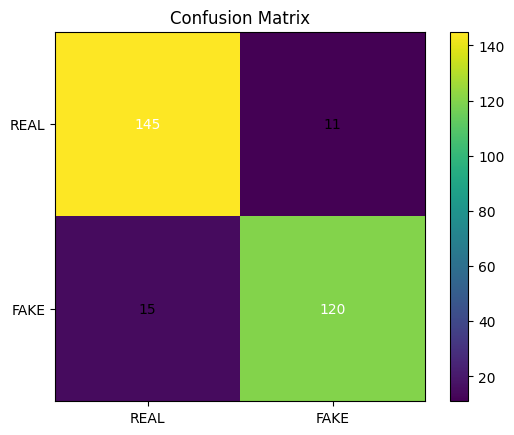

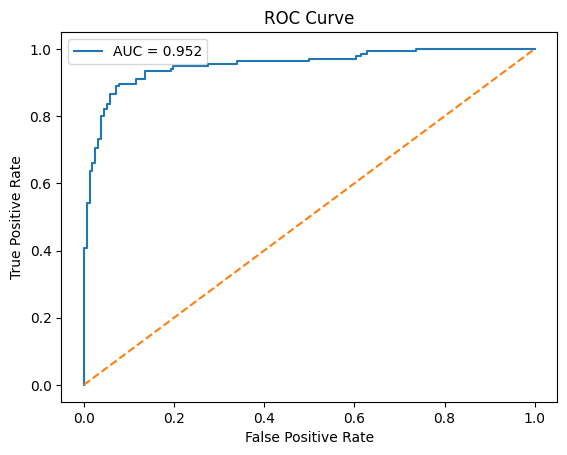


--- FINAL REPORT ---
Total Images: 400
REAL predicted: 160
FAKE predicted: 131
SUSPICIOUS: 109
Suspicious %: 27.25

Classification Metrics:
Accuracy: 0.9107
Precision: 0.916
Recall: 0.8889
F1 Score: 0.9023

AUC: 0.9522


In [1]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.fft import fft2, fftshift
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
# ---------------- PATHS ----------------
train_path = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train"
test_path  = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test"

output_dir = "/kaggle/working/output"
os.makedirs(output_dir, exist_ok=True)

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- PATCH EXTRACTION ----------------
def extract_patches(img, patch_size=96, stride=48, max_patches=60):
    patches = []
    h, w, _ = img.shape

    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])

    random.shuffle(patches)
    return patches[:max_patches]

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ---------------- CNN FEATURE ----------------
class CNNExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = torch.nn.Sequential(*list(model.children())[:-1])

    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
        return x.view(x.size(0), -1)

cnn_model = CNNExtractor().to(device)

# ---------------- ML FEATURES ----------------
def glcm_features(gray):
    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    return [graycoprops(glcm, 'contrast')[0,0],
            graycoprops(glcm, 'energy')[0,0]]

def lbp_features(gray):
    lbp = local_binary_pattern(gray, 8, 1)
    hist, _ = np.histogram(lbp.ravel(), bins=10)
    return hist/(np.sum(hist)+1e-6)

def fft_features(gray):
    f = fft2(gray)
    fshift = fftshift(f)
    mag = np.log(np.abs(fshift)+1)
    return [np.mean(mag), np.std(mag)]

# ---------------- PATCH FEATURE ----------------
def extract_patch_feature(patch):
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

    ml = np.concatenate([
        glcm_features(gray),
        lbp_features(gray),
        fft_features(gray)
    ])

    img_t = transform(patch).unsqueeze(0).to(device)
    cnn = cnn_model(img_t).cpu().numpy()[0]
    ml = ml / (np.linalg.norm(ml) + 1e-6)
    cnn = cnn / (np.linalg.norm(cnn) + 1e-6)

    combined = np.hstack([ml, cnn])
    return np.nan_to_num(combined)

# ---------------- LOAD DATA ----------------
def load_dataset(folder, label, max_images=700):
    X, y = [], []
    files = os.listdir(folder)[:max_images]

    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        if img is None:
            continue

        patches = extract_patches(img)
        feats = [extract_patch_feature(p) for p in patches]

        X.append(feats)
        y.append(label)

    return X, y

# ---------------- DATA PREP ----------------
real, y_real = load_dataset(os.path.join(train_path, "real"), 0)
fake, y_fake = load_dataset(os.path.join(train_path, "fake"), 1)

X = real + fake
y = y_real + y_fake

X_flat, y_flat = [], []
for i in range(len(X)):
    for p in X[i]:
        X_flat.append(p)
        y_flat.append(y[i])

X_flat = np.array(X_flat)
y_flat = np.array(y_flat)

scaler = StandardScaler()
X_flat = scaler.fit_transform(X_flat)

# ---------------- SPLIT ----------------
X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y_flat, test_size=0.2, stratify=y_flat, random_state=42
)

# ---------------- MODEL ----------------
model = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.2,
    reg_alpha=0.2,
    gamma=0.1,
    min_child_weight=3,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)

# ---------------- THRESHOLD SEARCH ----------------
def find_best_threshold():
    probs = model.predict_proba(X_val)[:,1]

    best_auc = 0
    best_t = 0.15

    for t in np.arange(0.04, 0.22, 0.005):
        valid_probs, valid_true = [], []

        for i in range(len(probs)):
            p = probs[i]
            diff = abs((1-p) - p)

            if diff < t:
                continue

            valid_probs.append(p)
            valid_true.append(y_val[i])

        if len(valid_true) < 50:
            continue

        fpr, tpr, _ = roc_curve(valid_true, valid_probs)
        score = auc(fpr, tpr)

        if score > best_auc:
            best_auc = score
            best_t = t

    print("Best Threshold:", best_t)
    print("Validation AUC:", best_auc)
    return best_t

best_threshold = find_best_threshold()

# ---------------- PREDICTION ----------------
def predict(img):
    patches = extract_patches(img)
    probs = []

    for p in patches:
        feat = extract_patch_feature(p)
        feat = scaler.transform([feat])
        prob = model.predict_proba(feat)[0]
        probs.append(prob)

    probs = np.array(probs)

    weights = np.max(probs, axis=1)**1.8
    avg_prob = np.average(probs, axis=0, weights=weights)

    diff = abs(avg_prob[0] - avg_prob[1])

    if diff < best_threshold * 0.90:
        return "SUSPICIOUS", avg_prob

    pred = np.argmax(avg_prob)
    return ("REAL" if pred == 0 else "FAKE"), avg_prob

# ---------------- EVALUATION ----------------
def evaluate(real_path, fake_path):
    y_true, y_pred, y_prob = [], [], []

    real_c = fake_c = susp_c = 0

    for f in os.listdir(real_path)[:200]:
        img = cv2.imread(os.path.join(real_path, f))
        if img is None:
            continue

        pred, prob = predict(img)

        if pred == "SUSPICIOUS":
            susp_c += 1
            continue

        y_true.append(0)
        y_pred.append(0 if pred=="REAL" else 1)
        y_prob.append(prob[1])

        real_c += (pred == "REAL")
        fake_c += (pred == "FAKE")

    for f in os.listdir(fake_path)[:200]:
        img = cv2.imread(os.path.join(fake_path, f))
        if img is None:
            continue

        pred, prob = predict(img)

        if pred == "SUSPICIOUS":
            susp_c += 1
            continue

        y_true.append(1)
        y_pred.append(0 if pred=="REAL" else 1)
        y_prob.append(prob[1])

        real_c += (pred == "REAL")
        fake_c += (pred == "FAKE")

    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xticks([0,1], ["REAL", "FAKE"])
    plt.yticks([0,1], ["REAL", "FAKE"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

    plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
    plt.colorbar()
    plt.show()
    plt.close()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.legend()
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.savefig(os.path.join(output_dir, "roc_curve.png"))
    plt.show()
    plt.close()

    total = real_c + fake_c + susp_c

    print("\n--- FINAL REPORT ---")
    print("Total Images:", total)
    print("REAL predicted:", real_c)
    print("FAKE predicted:", fake_c)
    print("SUSPICIOUS:", susp_c)
    print("Suspicious %:", round((susp_c/total)*100,2))

    print("\nClassification Metrics:")
    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1 Score:", round(f1,4))

    print("\nAUC:", round(roc_auc,4))

evaluate(
    os.path.join(test_path, "real"),
    os.path.join(test_path, "fake")
)